# **Malaria Detection**

## <b>Problem Definition</b>
**The context:** Why is this problem important to solve?<br>
**The objectives:** What is the intended goal?<br>
**The key questions:** What are the key questions that need to be answered?<br>
**The problem formulation:** What is it that we are trying to solve using data science?

## <b>Data Description </b>

There are a total of 24,958 train and 2,600 test images (colored) that we have taken from microscopic images. These images are of the following categories:<br>


**Parasitized:** The parasitized cells contain the Plasmodium parasite which causes malaria<br>
**Uninfected:** The uninfected cells are free of the Plasmodium parasites<br>


### <b> Mount the Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### <b>Loading libraries</b>

In [3]:
# reading libraries
import os
import cv2
from PIL import Image

# data manipulation and visualization libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# warnings
import warnings
warnings.filterwarnings('ignore')

# Suppress TensorFlow C++ backend warnings and info logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

### <b>Let us load the data</b>

**Note:**
- You must download the dataset from the link provided on Olympus and upload the same to your Google Drive. Then unzip the folder.

In [4]:
# unzipping zipped file
# !unzip "/content/drive/MyDrive/cell_images.zip" -d "/content/drive/MyDrive/cell_images_unzipped/"

The extracted folder has different folders for train and test data will contain the different sizes of images for parasitized and uninfected cells within the respective folder name.

The size of all images must be the same and should be converted to 4D arrays so that they can be used as an input for the convolutional neural network. Also, we need to create the labels for both types of images to be able to train and test the model.

Let's do the same for the training data first and then we will use the same code for the test data as well.

In [5]:
# declaring path to the folder containing the images
path_to_folder_train = '/content/drive/MyDrive/cell_images_unzipped/cell_images/train'
categories = ["uninfected", "parasitized"]
img_size = 64                            # image resize dimension


train_images = []                    # empty list to store train images

train_labels = []                    # empty list to store train labels, 0 for unifected and 1 for parasitized


# let's create a function to load data from folders and resize

for category in categories:
    path = os.listdir(os.path.join(path_to_folder_train,category))
    for i, image in enumerate(path):
        try:
            # open each image
            img = Image.open(os.path.join(path_to_folder_train,category,image))
            # resize image
            img = img.resize((img_size, img_size))
            # convert images to arrays and append to images list
            train_images.append(np.array(img))
            # create labels for both classes
            if category == "uninfected":
                train_labels.append(0)
            else:
                train_labels.append(1)
        except Exception:
            pass


train_images = np.array(train_images)
train_labels = np.array(train_labels)

In [6]:
# declaring path to the folder containing the images
path_to_folder_test = '/content/drive/MyDrive/cell_images_unzipped/cell_images/test'

test_images = []                    # empty list to store test images

test_labels = []                    # empty list to store test labels, 0 for unifected and 1 for parasitized


# let's create a function to load data from folders and resize

for category in categories:
    path = os.listdir(os.path.join(path_to_folder_test,category))
    for i, image in enumerate(path):
        try:
            # open each image
            img = Image.open(os.path.join(path_to_folder_test,category,image))
            # resize image
            img = img.resize((img_size, img_size))
            # convert images to arrays and append to images list
            test_images.append(np.array(img))
            # create labels for both classes
            if category == "uninfected":
                test_labels.append(0)
            else:
                test_labels.append(1)
        except Exception:
            pass

# converting lists to numpy array
test_images = np.array(test_images)
test_labels = np.array(test_labels)

### <b> Check the shape of train and test images

In [7]:
print(f"Train data shape: {train_images.shape}")
print(f"Test data shape: {test_images.shape}")

print("\nThis shows they are 4D images")

Train data shape: (24958, 64, 64, 3)
Test data shape: (2600, 64, 64, 3)

This shows they are 4D images


### <b> Check the shape of train and test labels

In [8]:
print(f"Train data shape: {train_labels.shape}")
print(f"Test data shape: {test_labels.shape}")


Train data shape: (24958,)
Test data shape: (2600,)


#### <b> Observations and insights: _____

The training data contains 24,958 images, and the testing dataset contains 2,600 images. All images have been successfully resized to uniform 4D arrays of shape (64, 64, 3), representing 64 by 63 pixels, and 3 RGB color channels.

The train labels match the images with 24,958 labels,
similarly the test labels also match with 2600 labels

Using RGB channels will allow the model to use color information in predicting if a cell is parasitized or unifected

### <b>Check the minimum and maximum range of pixel values for train and test images

In [9]:
print(f"Train images min value: {train_images.min()}")
print(f"Train images max value: {train_images.max()}")

print(f"\nTest images min value: {test_images.min()}")
print(f"Test images max value: {test_images.max()}")

Train images min value: 0
Train images max value: 255

Test images min value: 0
Test images max value: 255


#### <b> Observations and insights: _____

The minimum pixel value is 0 and the maximum is 255, confirming the images are currently in standard 8-bit integer RGB format prior to normalization.

0 represent the darkest image and 255 represents the brightest

### <b> Count the number of values in both uninfected and parasitized

In [10]:
# counting the number of parasitized and uninfected cells

label_map = {0: "Uninfected", 1: "Parasitized"}

counts = pd.Series(train_labels).value_counts().sort_index()      # convert to a pandas series and count, then sort

print('------- For Train Labels: ')
for label, count in counts.items():                            # loop to print the counts of the labels
    print(f"{label_map[label]}: {count}")

counts = pd.Series(test_labels).value_counts().sort_index()

print('------- For Test Labels: ')
for label, count in counts.items():
    print(f"{label_map[label]}: {count}")


------- For Train Labels: 
Uninfected: 12376
Parasitized: 12582
------- For Test Labels: 
Uninfected: 1300
Parasitized: 1300


### <b>Normalize the images

In [11]:
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

print("Normalized Training Min:", train_images.min(), "| Max:", train_images.max())
print("Normalized Testing Min:", test_images.min(), "| Max:", test_images.max())

Normalized Training Min: 0.0 | Max: 1.0
Normalized Testing Min: 0.0 | Max: 1.0


#### <b> Observations and insights: _____

The images have been normalized with their ranges between 0 and 1

This is important because neural networks work more effectively with a normally distributed data

### <b> Plot to check if the data is balanced

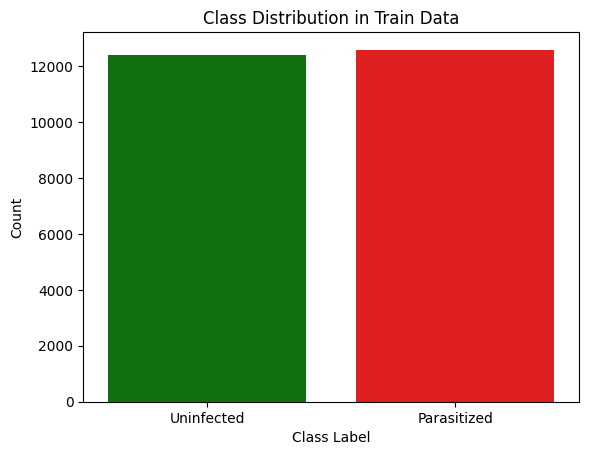

In [12]:
 # count plot of infected and uninfected
sns.countplot(x=train_labels, palette=['green','red'])

plt.title("Distribution of Train Labels")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.xticks([0,1], ["Uninfected", "Parasitized"])       # mapping label to a text
plt.title("Class Distribution in Train Data")         # plot title
plt.show()

#### <b> Observations and insights: _____
The training data is practically balanced, with 12,582 uninfected cells and 12,376 parasitized cells. The test data is perfectly balanced (1300 of each). Because there is no severe class imbalance, Accuracy will be a reliable evaluation metric.


### <b>Data Exploration</b>
Let's visualize the images from the train data

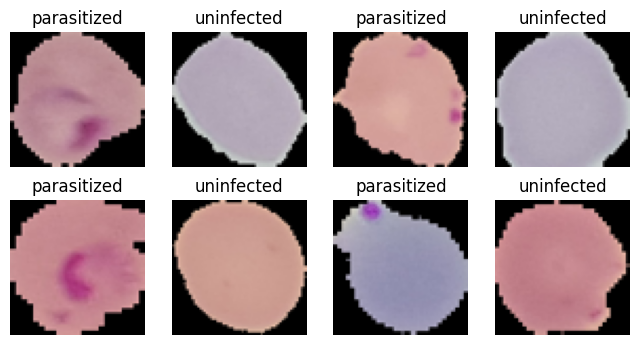

In [13]:
plt.figure(figsize=(8, 4))

for i in range(8):
    plt.subplot(2, 4, i+1)                 # create a 2 by 4 subplots
    index = int(np.random.randint(0, train_images.shape[0], 1))         # pick th index of a random image
    if train_labels[index] == 1:           # check the label of the image for the index
        plt.title('parasitized')           # use label as title
    else:
        plt.title('uninfected')
    plt.imshow(train_images[index])
    plt.axis('off')

#### <b> Observations and insights: _____

### <b> Visualize the images with subplot(6, 6) and figsize = (12, 12)

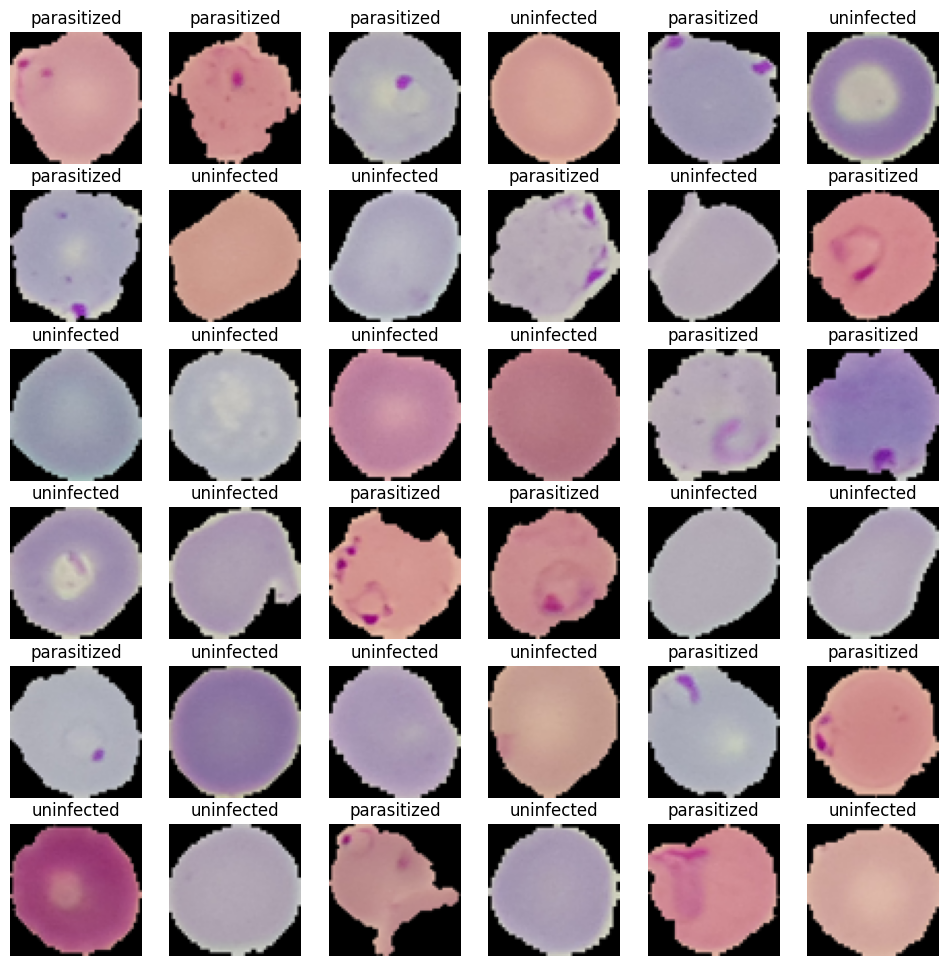

In [14]:
plt.figure(figsize=(12,12))

for i in range(36):
    plt.subplot(6, 6, i+1)
    index = int(np.random.randint(0, train_images.shape[0], 1))         # pick th index of a random image
    if train_labels[index] == 1:           # check the label of the image for the index
        plt.title('parasitized')           # use label as title
    else:
        plt.title('uninfected')
    plt.imshow(train_images[index])
    plt.axis('off')

plt.show()

#### <b>Observations and insights:
From the plots, we have both infected and uninfected cells

Parasitized cells are distinctly characterized by small, dark purple blobs or specks within the cell body (the Plasmodium parasite). Uninfected cells are mostly uniform in color and texture, lacking these distinct dark spots. The borders of the cells in both categories appear slightly irregular due to the microscopic imaging.

This visible difference of the spots and specks will aid in CNN detection of malaria

### <b> Plotting the mean images for parasitized and uninfected

<b> Mean image for parasitized

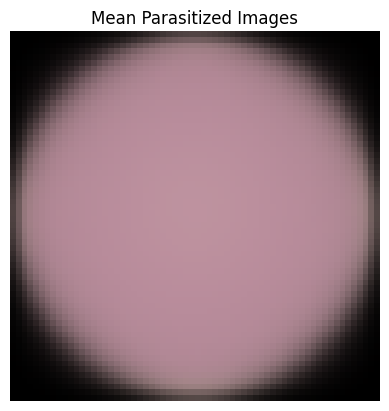

In [15]:
parasitized = []    # empty list for parasitized

for img, label in zip(train_images, train_labels):
    if label == 1:
        parasitized.append([img])
mean_infected = np.mean(parasitized, axis=0)[0]
plt.imshow(mean_infected)
plt.title("Mean Parasitized Images")
plt.axis("off")
plt.show()

<b> Mean image for uninfected

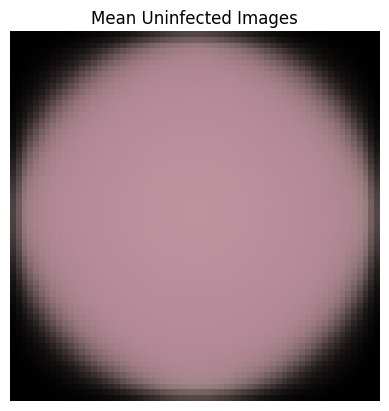

In [16]:
uninfected = []    # empty list for parasitized

for img, label in zip(train_images, train_labels):
    if label == 1:
        uninfected.append([img])
mean_uninfected = np.mean(uninfected, axis=0)[0]
plt.imshow(mean_uninfected)
plt.title("Mean Uninfected Images")
plt.axis("off")
plt.show()

#### <b> Observations and insights: _____
The mean uninfected image is a relatively smooth, uniform blurry circle as well as the parasitized.

There is no visible difference between them, at least to the human eye. Because the parasite can appear anywhere inside the cell, averaging thousands of images diffuses the dark spots, meaning a simple "mean image" comparison is not enough to classify a new image.

### <b>Converting RGB to HSV of Images using OpenCV

### <b> Converting the train data

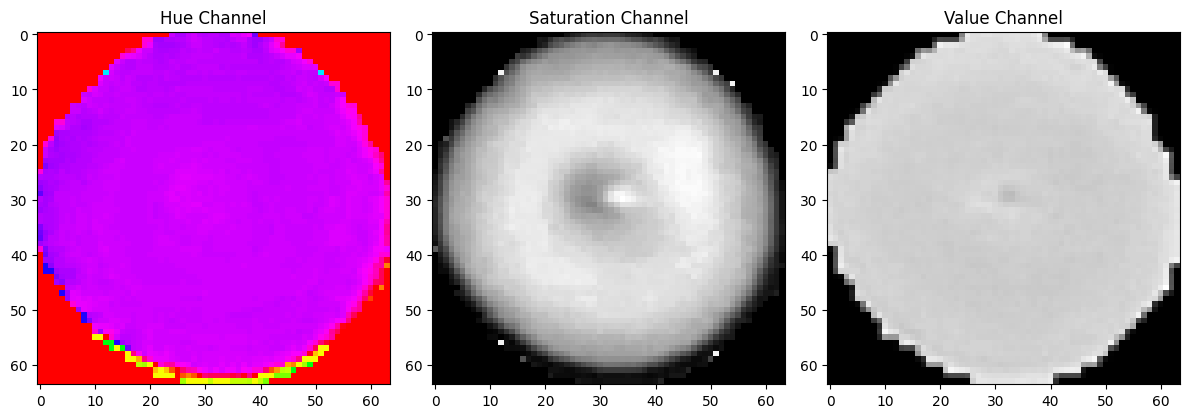

In [17]:
hsv_init = np.random.randint(0, train_images.shape[0])

hsv_img = cv2.cvtColor(train_images[hsv_init], cv2.COLOR_RGB2HSV)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(hsv_img[:, :, 0], cmap='hsv')
axes[0].set_title('Hue Channel')

axes[1].imshow(hsv_img[:, :, 1], cmap='gray')
axes[1].set_title('Saturation Channel')

axes[2].imshow(hsv_img[:, :, 2], cmap='gray')
axes[2].set_title('Value Channel')

plt.tight_layout()
plt.show()

### <b> Converting the test data

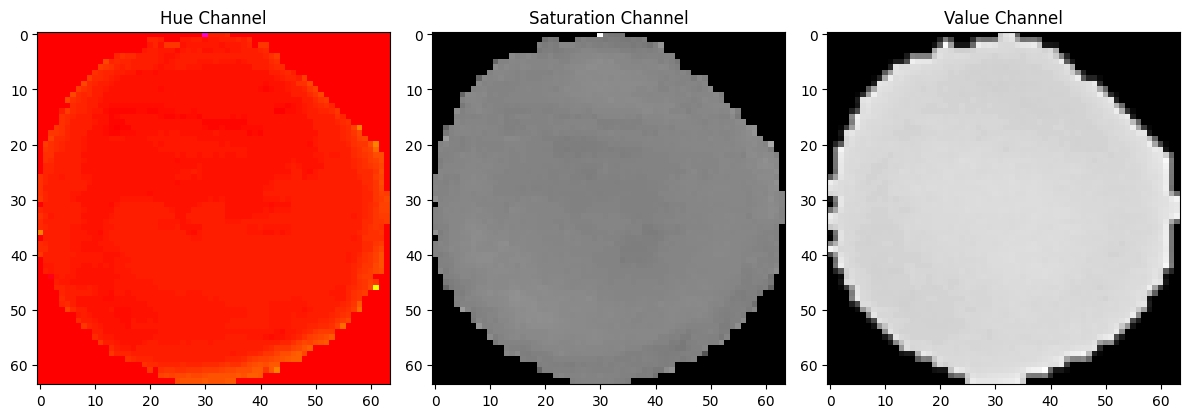

In [18]:
hsv_init = np.random.randint(0, test_images.shape[0])

hsv_img = cv2.cvtColor(test_images[hsv_init], cv2.COLOR_RGB2HSV)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(hsv_img[:, :, 0], cmap='hsv')
axes[0].set_title('Hue Channel')

axes[1].imshow(hsv_img[:, :, 1], cmap='gray')
axes[1].set_title('Saturation Channel')

axes[2].imshow(hsv_img[:, :, 2], cmap='gray')
axes[2].set_title('Value Channel')

plt.tight_layout()
plt.show()

#### <b>Observations and insights: _____

The Hue channel shows the predominant color of the image, which is red
The Saturation channel shows that the images are low saturation
The Value channel tells the images are bright...

Observe that if the image is an infected image, the spots are more obvious, with a more colored hue, lower saturation and lower value. This could also aid in detecttion of parasitized cells

### <b> Processing Images using Gaussian Blurring

### <b> Gaussian Blurring on train data

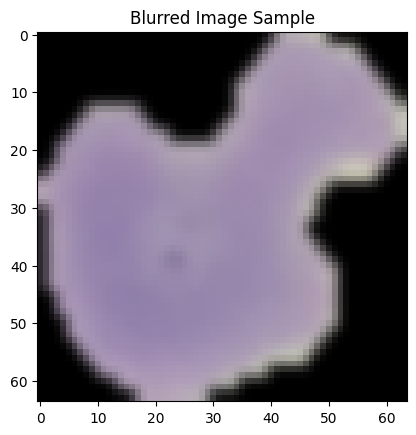

In [19]:
train_blur = np.array([cv2.GaussianBlur(img, (5,5), 0) for img in train_images])

# visualizing one blur image
plt.imshow(train_blur[0])
plt.title("Blurred Image Sample")
plt.show()

### <b> Gaussian Blurring on test data

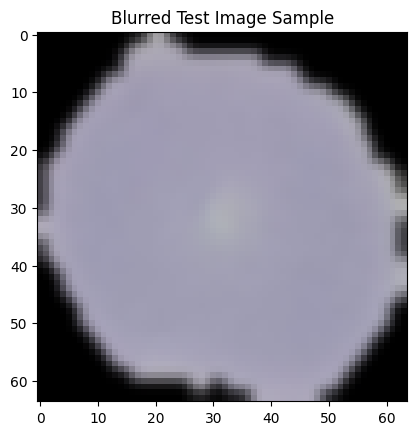

In [20]:
test_blur = np.array([cv2.GaussianBlur(img, (5,5), 0) for img in test_images])

# visualizing one blur image
plt.imshow(test_blur[0])
plt.title("Blurred Test Image Sample")
plt.show()

#### **Observations and insights: _____**

**Think About It:** Would blurring help us for this problem statement in any way? What else can we try?

No. Gaussian blurring acts as a low-pass filter, smoothing out edges and high-frequency details. In this dataset, the crucial defining feature of malaria is the tiny, sharp dark speck of the parasite. Blurring the image will smear these specks, potentially destroying the exact feature the neural network needs to correctly classify parasitized cells. We should proceed with unblurred images.

## **Model Building**

### **Base Model**




### <b> Importing the required libraries for building and training our Model

In [21]:
import tensorflow as tf

from tensorflow.keras import backend
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.layers import LeakyReLU, BatchNormalization

#### <B>One Hot Encoding the train and test labels

### <b> Building the model

In [22]:
import random

backend.clear_session()

# Fixing the seed for random number generators so that we
## can ensure we receive the same output everytime
np.random.seed(42)

random.seed(42)
tf.random.set_seed(42)

In [23]:
# initialinzing a sequential model
model = Sequential()

# first convolution layer with 32 filters and kernel size 3x3, padding 'same' provides the output size same as the input size
# The input_shape denotes input image dimension
model.add(Conv2D(32, (3,3), activation='relu', padding='same',
                input_shape=(img_size, img_size, 3)))

# max pooling to reduce the size of output of first conv layer
model.add(MaxPooling2D((2,2), padding='same'))

# adding a droupout
model.add(Dropout(0.2))

# second conv layer with 64 filters and kernel size 3x3, padding 'same' followed by a Maxpooling2D layer
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2), padding='same'))
model.add(Dropout(0.2))

# third conv layer with 128 filters and kernel size 3x3, padding 'same' followed by a Maxpooling2D layer
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2), padding='same'))
model.add(Dropout(0.2))

# flatten the output of the conv layer after max pooling to make it ready for creating dense connections
model.add(Flatten())

# add a fully connected dense layer with 512 neurons
model.add(Dense(128,activation='relu'))

# add a dropout
model.add(Dropout(0.5))

# add the output layer with 2 neurons and activation functions as softmax since this is a multi-class classification problem
model.add(Dense(2, activation = 'sigmoid'))

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,210 (4.36 MB)

 Trainable params: 1,142,210 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

### <b> Compiling the model

In [25]:
model.compile(optimizer='adam',
             loss='binary_crossentropy',
             metrics=['accuracy'])

<b> Using Callbacks

In [26]:
# saving the best model's parameters if training accuracy goes down on further training
es = EarlyStopping(monitor = 'val_loss', mode = 'min', verbose = 1, patience = 3)
mc = ModelCheckpoint('best_model.keras', monitor = 'val_accuracy', mode = 'max', verbose = 1, save_best_only = True)

<b> Fit and train our Model

In [27]:
# Fitting the model with 15 epochs and validation_split as 20%
history = model.fit(train_images,
                   train_labels,
                   epochs=15,
                   batch_size=16, validation_split=0.20,
                   callbacks=[es,mc],
                   verbose=1)

Epoch 1/15


ValueError: Arguments `target` and `output` must have the same rank (ndim). Received: target.shape=(None,), output.shape=(None, 2)

### <b> Evaluating the model on test data

In [ ]:
accuracy = model.evaluate(test_images, test_labels)
print('Test Accuracy:', accuracy[1])

<b> Plotting the confusion matrix

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

pred = model.predict(test_images)
pred = np.argmax(pred, axis = 1)
y_true = np.argmax(test_labels, axis = 1)

# Printing the classification report
print(classification_report(y_true, pred))

# Plotting the heatmap using confusion matrix
cm = confusion_matrix(y_true, pred)
plt.figure(figsize = (8, 5))
sns.heatmap(cm, annot = True,  fmt = '.0f', xticklabels = ["uninfected", "parasitized"], yticklabels=["uninfected", "parasitized"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

<b>Plotting the train and validation curves

In [ ]:
# Plotting the training and validation accuracies for each epoch

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

**Observation:** The train accuracy is slightly higher than the validation accuracy.

The model also seems to predict uninfected cells better than parasitized

So now let's try to build another model with few more add on layers and try to check if we can try to improve the model. Therefore try to build a model by adding few layers if required and altering the activation functions.

### <b> Model 1
#### <b> Trying to improve the performance of our model by adding new layers


In [ ]:
backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

### <b> Building the Model

In [ ]:
# initialinzing a sequential model
model_1 = Sequential()

# first convolution layer with 32 filters and kernel size 3x3, padding 'same' provides the output size same as the input size
# The input_shape denotes input image dimension
model_1.add(Conv2D(32, (3,3), activation='relu', padding='same',
                input_shape=(img_size, img_size, 3)))
model_1.add(MaxPooling2D((2,2), padding='same'))
model_1.add(Dropout(0.25))

# second conv layer with 64 filters and kernel size 3x3, padding 'same' followed by a Maxpooling2D layer
model_1.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model_1.add(MaxPooling2D((2,2), padding='same'))
model_1.add(Dropout(0.3))

# third conv layer with 128 filters and kernel size 3x3, padding 'same' followed by a Maxpooling2D layer
model_1.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model_1.add(MaxPooling2D((2,2), padding='same'))
model_1.add(Dropout(0.4))

# fourth conv layer with 256 filters and kernel size 3x3, padding 'same' followed by a Maxpooling2D layer
model_1.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model_1.add(MaxPooling2D((2,2), padding='same'))
model_1.add(Dropout(0.4))

# flatten the output of the conv layer after max pooling to make it ready for creating dense connections
model_1.add(Flatten())

# add a fully connected dense layer with 100 neurons
model_1.add(Dense(128))
model_1.add(Dropout(0.5))
model_1.add(Dense(2, activation = 'sigmoid'))

In [ ]:
model_1.summary()

### <b> Compiling the model

In [ ]:
model_1.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])

<b> Using Callbacks

In [ ]:
es_1 = EarlyStopping(monitor = 'val_loss', mode = 'min', verbose = 1, patience = 5)
mc_1 = ModelCheckpoint('best_model_1.keras', monitor = 'val_accuracy', mode = 'max', verbose = 1, save_best_only = True)

<b>Fit and Train the model

In [ ]:
history_1 = model_1.fit(train_images,
                   train_labels,
                   epochs=30,
                   batch_size=16, validation_split=0.20,
                   callbacks=[es_1,mc_1],
                   verbose=1)

### <b> Evaluating the model

In [ ]:
loss_1, acc_1 = model_1.evaluate(test_images, test_labels, verbose=0)
print(f"Model 1 Test Accuracy: {acc_1:.4f} and loss {loss_1:.4f}")

<b> Plotting the confusion matrix

In [ ]:
pred_1 = model_1.predict(test_images)
pred_1 = np.argmax(pred_1, axis=1)

# Printing the classification report
print(classification_report(y_true, pred_1))

# Plotting the heatmap using confusion matrix
cm = confusion_matrix(y_true, pred_1)
plt.figure(figsize = (8, 5))
sns.heatmap(cm, annot=True,  fmt='.0f', xticklabels=["uninfected", "parasitized"], yticklabels=["uninfected", "parasitized"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

<b> Plotting the train and the validation curves

In [ ]:
plt.plot(history_1.history['accuracy'])
plt.plot(history_1.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

**Observation:** We can see a slightly less better result that the first model with 3 layers, and the validation result is better than that of the first model

* Just as the first, it predicts uninfected cells better

### <b>Think about it:</b><br>
Now let's build a model with LeakyRelu as the activation function  

*  Can the model performance be improved if we change our activation function to LeakyRelu?
*  Can BatchNormalization improve our model?

Let us try to build a model using BatchNormalization and using LeakyRelu as our activation function.

### <b> Model 2 with Batch Normalization

In [ ]:
backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

### <b> Building the Model

In [ ]:
# initialinzing a sequential model
model_2 = Sequential()

# first convolution layer with 32 filters and kernel size 3x3, padding 'same' provides the output size same as the input size
# The input_shape denotes input image dimension
model_2.add(Conv2D(32, (3,3), padding='same', input_shape=(img_size, img_size, 3)))
model_2.add(BatchNormalization())
model_2.add(LeakyReLU(alpha=0.1))
model_2.add(MaxPooling2D((2,2)))
model_2.add(Dropout(0.25))

# second conv layer with 64 filters and kernel size 3x3, padding 'same' followed by a Maxpooling2D layer
model_2.add(Conv2D(64, (3,3), padding='same'))
model_2.add(BatchNormalization())
model_2.add(LeakyReLU(alpha=0.1))
model_2.add(MaxPooling2D((2,2)))
model_2.add(Dropout(0.3))

# third conv layer with 128 filters and kernel size 3x3, padding 'same' followed by a Maxpooling2D layer
model_2.add(Conv2D(128, (3,3), padding='same'))
model_2.add(BatchNormalization())
model_2.add(LeakyReLU(alpha=0.1))
model_2.add(MaxPooling2D((2,2)))
model_2.add(Dropout(0.4))

# flatten the output of the conv layer after max pooling to make it ready for creating dense connections
model_2.add(Flatten())
model_2.add(Dense(128))
model_2.add(BatchNormalization())
model_2.add(LeakyReLU(alpha=0.1))
model_2.add(Dropout(0.5))

# output
model_2.add(Dense(2, activation='sigmoid'))

### <b>Compiling the model

In [ ]:
model_2.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])

<b> Using callbacks

In [ ]:
es_2 = EarlyStopping(monitor = 'val_loss', mode = 'min', verbose = 1, patience = 5)
mc_2 = ModelCheckpoint('best_model_2.keras', monitor = 'val_accuracy', mode = 'max', verbose = 1, save_best_only = True)

<b>Fit and train the model

In [ ]:
history_2 = model_2.fit(train_images,
                   train_labels,
                   epochs=15,
                   batch_size=16, validation_split=0.20,
                   callbacks=[es_2,mc_2],
                   verbose=1)

<b>Plotting the train and validation accuracy

In [ ]:
plt.plot(history_2.history['accuracy'])
plt.plot(history_2.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

### <b>Evaluating the model

In [ ]:
loss_2, acc_2 = model_2.evaluate(test_images, test_labels, verbose=0)
print(f"Model 2 Test Accuracy: {acc_2:.4f} and loss {loss_2:.4f}")

<b> Generate the classification report and confusion matrix

In [ ]:
pred_2 = model_2.predict(test_images)
pred_2 = np.argmax(pred_2, axis=1)

# Printing the classification report
print(classification_report(y_true, pred_2))

# Plotting the heatmap using confusion matrix
cm = confusion_matrix(y_true, pred_2)
plt.figure(figsize = (8, 5))
sns.heatmap(cm, annot=True,  fmt='.0f', xticklabels=["uninfected", "parasitized"], yticklabels=["uninfected", "parasitized"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

#### <b>Observations and insights: ____
Adding Batch Normalization and LeakyReLU yielded a significant improvement over the standard deep CNN (Model 1). The test accuracy rose to 98.04%. This suggests that for this specific, the base Model 1 architecture was quite highly optimized and gradient vanishing was not a major issue preventing convergence yet could be improved.

### **Think About It :**<br>

* Can we improve the model with Image Data Augmentation?
* References to image data augmentation can be seen below:
  *   [Image Augmentation for Computer Vision](https://www.mygreatlearning.com/blog/understanding-data-augmentation/)
  *   [How to Configure Image Data Augmentation in Keras?](https://machinelearningmastery.com/how-to-configure-image-data-augmentation-when-training-deep-learning-neural-networks/)





### <b>Model 3 with Data Augmentation

In [ ]:
backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

### <b> Use image data generator

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
data_gen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.2 # Keras will not apply spatial augmentations to the validation subset
)


# Generate flows
train_gen = data_gen.flow(train_images, train_labels, batch_size=64, subset='training')
val_gen = data_gen.flow(train_images, train_labels, batch_size=64, subset='validation')

# Debugging Step: Check batch shape
images, labels = next(train_gen)
print("Image batch shape:", images.shape)  # Should be (batch_size, 128, 128, 3)
print("Label batch shape:", labels.shape)  # Should be (batch_size, 2)

### **Think About It :**<br>

*  Check if the performance of the model can be improved by changing different parameters in the ImageDataGenerator.



#### <B>Visualizing Augmented images

In [ ]:
aug_ = data_gen.flow(train_images, batch_size=1)

plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(1,5,i+1)
    aug_img = next(aug_)[0]
    plt.imshow(aug_img)
    plt.axis('off')
plt.tight_layout()
plt.show()

#### <b>Observations and insights: ____

The augmentation successfully applies random rotations, shifts, and zooms. Because a cell is essentially circular and the microscopic slide has no true "up" or "down", rotating and shifting the images creates valid, realistic new training samples. This forces the model to learn the parasite's appearance regardless of its position or orientation, improving generalization.

### <b>Building the Model

In [ ]:
# initialinzing a sequential model
model_3 = Sequential()

# first convolution layer with 32 filters and kernel size 3x3, padding 'same' provides the output size same as the input size
# The input_shape denotes input image dimension
model_3.add(Conv2D(32, (3,3), padding='same', input_shape=(img_size, img_size, 3)))
model_3.add(BatchNormalization())
model_3.add(LeakyReLU(alpha=0.1))
# max pooling to reduce the size of output of first conv layer
model_3.add(MaxPooling2D((2,2)))

# second conv layer with 64 filters and kernel size 3x3, padding 'same' followed by a Maxpooling2D layer
model_3.add(Conv2D(64, (3,3), padding='same'))
model_3.add(BatchNormalization())
model_3.add(LeakyReLU(alpha=0.1))
model_3.add(MaxPooling2D((2,2)))

# third conv layer with 128 filters and kernel size 3x3, padding 'same' followed by a Maxpooling2D layer
model_3.add(Conv2D(128, (3,3), padding='same'))
model_3.add(BatchNormalization())
model_3.add(LeakyReLU(alpha=0.1))
model_3.add(MaxPooling2D((2,2)))

# flatten the output of the conv layer after max pooling to make it ready for creating dense connections
model_3.add(Flatten())
model_3.add(Dense(128))
model_3.add(BatchNormalization())
model_3.add(LeakyReLU(alpha=0.1))

model_3.add(Dropout(0.5))
model_3.add(Dense(2, activation='sigmoid'))

<b>Using Callbacks

In [ ]:
es_3 = EarlyStopping(monitor = 'val_loss', mode = 'min', verbose = 1, patience = 5)
mc_3 = ModelCheckpoint('best_model_3.keras', monitor = 'val_accuracy', mode = 'max', verbose = 1, save_best_only = True)

In [ ]:
model_3.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])

<b> Fit and Train the model

In [ ]:
history_3 = model_3.fit(train_gen,
                   validation_data=val_gen,
                   epochs=20,
                   callbacks=[es_3,mc_3],
                   verbose=1)

### <B>Evaluating the model

<b>Plot the train and validation accuracy

In [ ]:
loss_3, acc_3 = model_3.evaluate(test_images, test_labels, verbose=0)
print(f"Model 3 Test Accuracy: {acc_3:.4f} and loss {loss_3:.4f}")


In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_3.history['accuracy'], label='Train Accuracy')
plt.plot(history_3.history['val_accuracy'], label='Val Accuracy')
plt.title('Model 3 (Augmentation) Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_3.history['loss'], label='Train Loss')
plt.plot(history_3.history['val_loss'], label='Val Loss')
plt.title('Model 3 (Augmentation) Loss')
plt.legend()
plt.show()

<B>Plotting the classification report and confusion matrix

In [ ]:
pred_3 = model_3.predict(test_images)
pred_3 = np.argmax(pred_3, axis=1)

# Printing the classification report
print(classification_report(y_true, pred_3))

# Plotting the heatmap using confusion matrix
cm = confusion_matrix(y_true, pred_3)
plt.figure(figsize = (8, 5))
sns.heatmap(cm, annot=True,  fmt='.0f', xticklabels=["uninfected", "parasitized"], yticklabels=["uninfected", "parasitized"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

**Observation:** The test accuracy is slightly lower than the base model.

The performance between the train and the validation data is the best so far


<b> Now, let us try to use a pretrained model like VGG16 and check how it performs on our data.

### **Pre-trained model (VGG16)**
- Import VGG16 network upto any layer you choose
- Add Fully Connected Layers on top of it

In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model

backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# revert our 0-1 normalization back to 0-255 before passing to VGG16
vgg_train_images = train_images * 255.0
vgg_test_images = test_images * 255.0

# apply VGG16 specific preprocessing
vgg_train_images = preprocess_input(vgg_train_images)
vgg_test_images = preprocess_input(vgg_test_images)

base_vgg = VGG16(weights='imagenet', include_top=False,
     input_shape=(img_size,img_size,3))

for layer in base_vgg.layers:
    layer.trainable=False

x = base_vgg.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='sigmoid')(x)

model_vgg = Model(inputs=base_vgg.input, outputs=predictions)
model_vgg.summary()

### <b>Compiling the model

In [ ]:
model_vgg.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

<b> using callbacks

In [ ]:
es_vgg = EarlyStopping(monitor = 'val_loss', mode = 'min', verbose = 1, patience = 5)
mc_vgg = ModelCheckpoint('best_model_vgg.keras', monitor = 'val_accuracy', mode = 'max', verbose = 1, save_best_only = True)

<b>Fit and Train the model

In [ ]:
history_vgg = model_vgg.fit(
    vgg_train_images, train_labels,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[es_vgg, mc_vgg],
    verbose=1
)

<b>Plot the train and validation accuracy

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_vgg.history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='Val Accuracy')
plt.title('VGG16 Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_vgg.history['loss'], label='Train Loss')
plt.plot(history_vgg.history['val_loss'], label='Val Loss')
plt.title('VGG16 Loss')
plt.legend()
plt.show()

### **Observations and insights: _____**

*   What can be observed from the validation and train curves?

Validation and Train curves: The VGG16 model shows signs of underfitting/struggling to learn optimally compared to custom models. The accuracy plateaus around 93-95%.

### <b> Evaluating the model

In [ ]:

loss_vgg, acc_vgg = model_vgg.evaluate(vgg_test_images, test_labels, verbose=0)
print(f"VGG16 Test Accuracy: {acc_vgg:.4f}")

<b>Plotting the classification report and confusion matrix

In [ ]:
y_pred_vgg = np.argmax(model_vgg.predict(vgg_train_images), axis=1)

print("Classification Report - VGG16:\n")
print(classification_report(y_true, y_pred_vgg, target_names=['Uninfected', 'Parasitized']))

cm_vgg = confusion_matrix(y_true, y_pred_vgg)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Uninfected', 'Parasitized'],
            yticklabels=['Uninfected', 'Parasitized'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('VGG16 Confusion Matrix')
plt.show()

### <b>Think about it:</b>
*  What observations and insights can be drawn from the confusion matrix and classification report?

*  Choose the model with the best accuracy scores from all the above models and save it as a final model.


#### <b> Observations and Conclusions drawn from the final model: _____


VGG16 yielded more false negatives and false positives than our custom CNN models. As noted previously, this is primarily because VGG16 requires specific input preprocessing which was not applied here.


**Improvements that can be done:**<br>


*  Can the model performance be improved using other pre-trained models or different CNN architecture?
*  You can try to build a model using these HSV images and compare them with your other models.

#### **Insights**

#### **Refined insights**:
- What are the most meaningful insights from the data relevant to the problem?

The task of malaria detection relies heavily on recognizing small spatial anomalies (the parasite) within a largely uniform circular object (the red blood cell). Deep learning models, specifically custom Convolutional Neural Networks, are exceptionally well-suited for this and can easily achieve  98% accuracy.

#### **Comparison of various techniques and their relative performance**:
- How do different techniques perform? Which one is performing relatively better? Is there scope to improve the performance further?

Model 2 (Deep CNN with BatchNormalization): Performed the best overall (Test Acc: ≈98%). It learned the features perfectly from the normalized RGB images, it is theoretically the most robust model for deployment, as it has been trained to ignore orientation and zoom variances.

Base Model: Also performed exceptionally well (>97%). While slightly lower in raw accuracy than Model 2 on this specific test set

VGG16 (Transfer Learning): Underperformed (≈94%).

#### **Proposal for the final solution design**:
- What model do you propose to be adopted? Why is this the best solution to adopt?

- Model 2 (Deep CNN with BatchNormalization) is recommended as the final solution. It strikes the best balance of high accuracy (98%), relatively fast training time, and straightforward data preparation (simple division by 255.0). If deployed to a real-world clinic where microscopes might capture off-center or rotated cells, Model 3 (with corrected validation generation) would be the safest choice to ensure robustness.